### Mounting Drive and Setting up Kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/deepfake_audio'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, 'checkpoints'), exist_ok=True)
print(f"Project dir: {PROJECT_DIR}" )

Mounted at /content/drive
Project dir: /content/drive/MyDrive/deepfake_audio


In [3]:
!pip install -q librosa==0.10.2 soundfile audiomentations==0.35.0 pydub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 22.9 MB/s eta 0:00:00


In [4]:
from google.colab import files
print("Upload your kaggle.json now:")
uploaded = files.upload()

Upload your kaggle.json now:


Saving kaggle.json to kaggle.json


In [5]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [6]:
import os
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset -p {DATA_DIR}

!unzip -q {DATA_DIR}/the-fake-or-real-dataset.zip -d {DATA_DIR}/for

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [02:04<00:00, 138MB/s]



### Loading Dataset Paths

In [7]:
import pandas as pd

TRAIN_DIR = '/content/data/for/for-norm/for-norm/training'
REAL_DIR  = os.path.join(TRAIN_DIR, 'real')
FAKE_DIR  = os.path.join(TRAIN_DIR, 'fake')

def list_audio(folder, label):
    rows = []
    for f in os.listdir(folder):
        if f.lower().endswith(('.wav', '.flac', '.mp3')):
            rows.append({'path': os.path.join(folder, f), 'label': label})
    return rows

rows = list_audio(REAL_DIR, 'real') + list_audio(FAKE_DIR, 'fake')
df = pd.DataFrame(rows)

print("Total files:", len(df))
print(df['label'].value_counts())

Total files: 53868
label
real    26941
fake    26927
Name: count, dtype: int64


### EDA

In [8]:
import soundfile as sf
import numpy as np

def probe(path):
    try:
        info = sf.info(path)
        return info.frames / info.samplerate, info.samplerate, info.channels
    except Exception:
        return None, None, None

audit = df.groupby('label', group_keys=False).apply(
    lambda g: g.sample(min(len(g), 1500), random_state=0)
).copy()

durs, srs, chs = [], [], []

for p in audit['path']:
    d, s, c = probe(p)
    durs.append(d)
    srs.append(s)
    chs.append(c)

audit['duration'] = durs
audit['sr'] = srs
audit['channels'] = chs
audit = audit.dropna(subset=['duration'])

print("Sample rates by class:")
print(audit.groupby('label')['sr'].value_counts())
print("\nChannels by class:")
print(audit.groupby('label')['channels'].value_counts())

/tmp/ipykernel_1228/397494676.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  audit = df.groupby('label', group_keys=False).apply(


Sample rates by class:
label  sr   
fake   16000    1500
real   16000    1500
Name: count, dtype: int64

Channels by class:
label  channels
fake   1           1500
real   1           1500
Name: count, dtype: int64


In [9]:
print(audit.groupby('label')['duration'].describe()[['mean','std','min','25%','50%','75%','max']])

           mean       std       min       25%       50%       75%        max
label                                                                       
fake   1.691217  0.730945  0.332437  1.166250  1.564344  2.057969   5.361562
real   4.528169  2.353298  0.000000  2.757656  3.870875  6.115000  17.581375


In [10]:
import librosa

def silence_loudness(path, top_db=30):
    try:
        y, sr = librosa.load(path, sr=16000, mono=True)
        if len(y) == 0:
            return None, None, None
        rms = float(np.sqrt(np.mean(y**2)))
        # Compare trimmed length to original to estimate silence fraction.
        yt, _ = librosa.effects.trim(y, top_db=top_db)
        silence_frac = 1.0 - (len(yt) / len(y)) if len(y) > 0 else 0.0
        return rms, silence_frac, len(y)/sr
    except Exception:
        return None, None, None

# Smaller sample here since we fully decode (slower).
small = audit.groupby('label', group_keys=False).apply(
    lambda g: g.sample(min(len(g), 400), random_state=1)
).copy()

rmss, sils = [], []
for p in small['path']:
    r, s, _ = silence_loudness(p)
    rmss.append(r); sils.append(s)
small['rms'] = rmss
small['silence_frac'] = sils
small = small.dropna(subset=['rms'])

print("Loudness (RMS) by class:")
print(small.groupby('label')['rms'].describe()[['mean','std','50%']])
print("\nSilence fraction by class:")
print(small.groupby('label')['silence_frac'].describe()[['mean','std','50%']])

/tmp/ipykernel_1228/2343059407.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  small = audit.groupby('label', group_keys=False).apply(


Loudness (RMS) by class:
           mean       std       50%
label                              
fake   0.183163  0.040115  0.180752
real   0.150319  0.065663  0.138505

Silence fraction by class:
       mean  std  50%
label                
fake    0.0  0.0  0.0
real    0.0  0.0  0.0


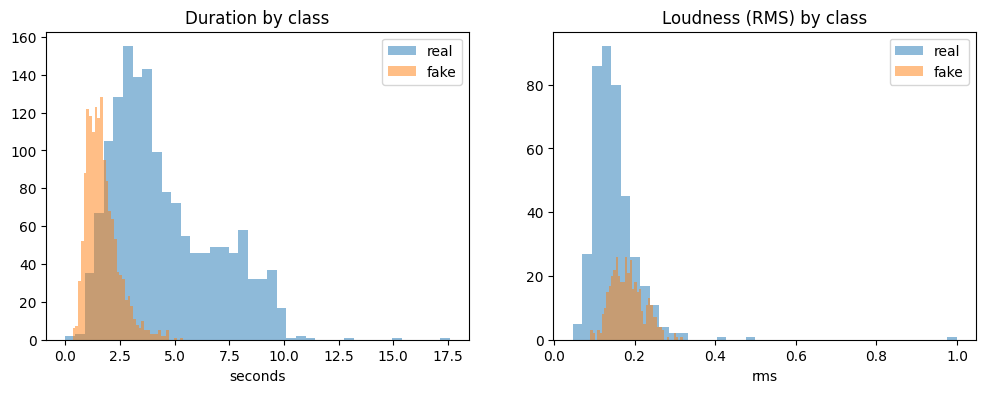

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lab in ['real', 'fake']:
    axes[0].hist(audit[audit.label==lab]['duration'], bins=40, alpha=0.5, label=lab)
    axes[1].hist(small[small.label==lab]['rms'], bins=40, alpha=0.5, label=lab)

axes[0].set_title('Duration by class')
axes[0].set_xlabel('seconds')
axes[0].legend()

axes[1].set_title('Loudness (RMS) by class')
axes[1].set_xlabel('rms')
axes[1].legend()

plt.show()

### Preprocessing

In [12]:
SR            = 16000
DURATION      = 3.0
N_SAMPLES     = int(SR * DURATION) # 48000 samples
N_MELS        = 64
N_FFT         = 1024
HOP_LENGTH    = 256
TARGET_RMS    = 0.05

In [13]:
def fix_length(y, train=False):
    """Force waveform to exactly N_SAMPLES.
    - Short clips: repeat-pad
    - Long clips: random 3s window in training (augmentation), center window at inference.
    """
    n = len(y)
    if n < N_SAMPLES:
        reps = int(np.ceil(N_SAMPLES / n))
        y = np.tile(y, reps)[:N_SAMPLES]
    elif n > N_SAMPLES:
        if train:
            start = np.random.randint(0, n - N_SAMPLES + 1)
        else:
            start = (n - N_SAMPLES)//2
        y = y[start:start + N_SAMPLES]
    return y

def loudness_normalize(y, target_rms=TARGET_RMS):
    # Scale so every clip has the same RMS. Removes loudness as a class cue.
    rms = np.sqrt(np.mean(y**2)) + 1e-9
    return y * (target_rms / rms)

def waveform_to_logmel(y):
    # Log-mel spectrogram, then per-spectrogram standardization.
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    logmel = librosa.power_to_db(mel, ref=np.max) # dB scale
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-9)
    return logmel.astype(np.float32)

def preprocess(path_or_array, train=False, sr_in=None):
    if isinstance(path_or_array, str):
        y, _ = librosa.load(path_or_array, sr=SR, mono=True) # load + resample + mono
    else:
        y = np.asarray(path_or_array, dtype=np.float32)
        if y.ndim > 1:  # stereo -> mono
            y = y.mean(axis=1)
        if sr_in is not None and sr_in != SR:
            y = librosa.resample(y, orig_sr=sr_in, target_sr=SR)

    y = fix_length(y, train=train)
    y = loudness_normalize(y)
    return waveform_to_logmel(y)

Real spectrogram shape: (64, 188)
Fake spectrogram shape: (64, 188)
True


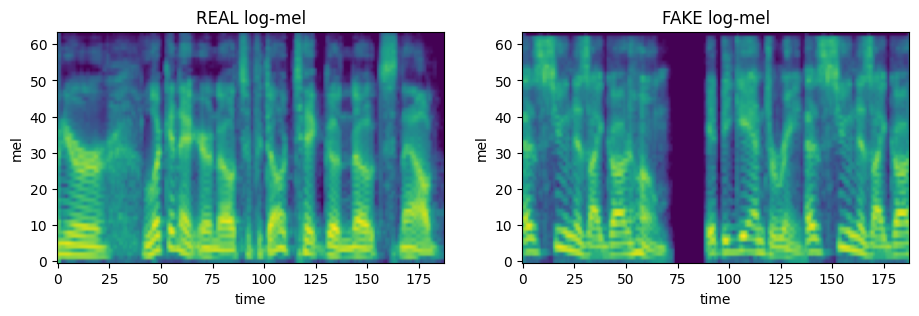

In [14]:
import matplotlib.pyplot as plt
import os

TRAIN_DIR = '/content/data/for/for-norm/for-norm/training'
real_ex = os.path.join(TRAIN_DIR, 'real', os.listdir(os.path.join(TRAIN_DIR,'real'))[0])
fake_ex = os.path.join(TRAIN_DIR, 'fake', os.listdir(os.path.join(TRAIN_DIR,'fake'))[0])

m_real = preprocess(real_ex)
m_fake = preprocess(fake_ex)

print("Real spectrogram shape:", m_real.shape)
print("Fake spectrogram shape:", m_fake.shape)
print(m_real.shape == m_fake.shape) # Both must be identical

fig, ax = plt.subplots(1, 2, figsize=(11,3))
ax[0].imshow(m_real, origin='lower', aspect='auto')
ax[0].set_title('REAL log-mel')

ax[1].imshow(m_fake, origin='lower', aspect='auto')
ax[1].set_title('FAKE log-mel')

for a in ax: a.set_xlabel('time'); a.set_ylabel('mel')

plt.show()

In [15]:
import soundfile as sf

# Grab a very short fake and a very long real to stress-test.
def dur(p):
    info = sf.info(p); return info.frames / info.samplerate

reals = [os.path.join(TRAIN_DIR,'real',f) for f in os.listdir(os.path.join(TRAIN_DIR,'real'))[:200]]
fakes = [os.path.join(TRAIN_DIR,'fake',f) for f in os.listdir(os.path.join(TRAIN_DIR,'fake'))[:200]]

longest  = max(reals, key=dur)
shortest = min(fakes, key=dur)
print(f"Longest real: {dur(longest):.2f}s  ->  shape {preprocess(longest).shape}")
print(f"Shortest fake: {dur(shortest):.2f}s  ->  shape {preprocess(shortest).shape}")
print("Leak neutralized:", preprocess(longest).shape == preprocess(shortest).shape)

Longest real: 14.51s  ->  shape (64, 188)
Shortest fake: 0.49s  ->  shape (64, 188)
Leak neutralized: True


In [16]:
# Augmentation

from audiomentations import Compose, AddGaussianNoise, Gain, PitchShift
import numpy as np

class CheapCodecDegrade:
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, samples, sample_rate):
        if np.random.rand() > self.p:
            return samples
        y = samples.astype(np.float32)
        # mu-law compand/expand -> quantization-like artifact
        mu = np.random.choice([64, 128, 255])
        comp = np.sign(y) * np.log1p(mu * np.abs(y)) / np.log1p(mu)
        q = np.round(comp * 32) / 32.0 # coarse quantize
        y = np.sign(q) * (1.0/mu) * (np.expm1(np.log1p(mu) * np.abs(q)))
        return y.astype(np.float32)

cheap_codec = CheapCodecDegrade(p=0.5)

base_aug = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.4),
    Gain(min_gain_db=-6, max_gain_db=6, p=0.3),
])

def wave_augment(samples, sample_rate):
    s = cheap_codec(samples, sample_rate)        # cheap MP3-substitute
    s = base_aug(samples=s, sample_rate=sample_rate)
    return s

def spec_augment(logmel, n_time_masks=2, n_freq_masks=2,
                 max_time=20, max_freq=8, p=0.5):
    if np.random.rand() > p:
        return logmel
    spec = logmel.copy()
    n_mels, n_time = spec.shape
    fill = spec.min()

    for _ in range(n_freq_masks):
        f = np.random.randint(0, max_freq + 1)
        if f > 0:
            f0 = np.random.randint(0, max(1, n_mels - f))
            spec[f0:f0+f, :] = fill
    for _ in range(n_time_masks):
        t = np.random.randint(0, max_time + 1)
        if t > 0:
            t0 = np.random.randint(0, max(1, n_time - t))
            spec[:, t0:t0+t] = fill
    return spec

In [17]:
import librosa

def preprocess_augmented(path):
    y, _ = librosa.load(path, sr=SR, mono=True)

    y = wave_augment(samples=y.astype(np.float32), sample_rate=SR)

    y = fix_length(y, train=True)
    y = loudness_normalize(y)
    logmel = waveform_to_logmel(y)

    logmel = spec_augment(logmel)
    return logmel

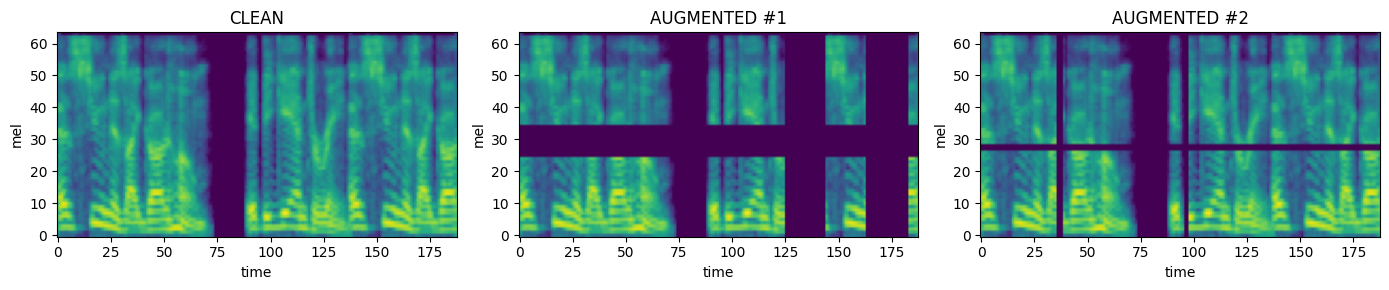

Aug #1 and #2 should differ True


In [18]:
import matplotlib.pyplot as plt
import os

fake_ex = os.path.join(TRAIN_DIR, 'fake', os.listdir(os.path.join(TRAIN_DIR,'fake'))[0])

clean = preprocess(fake_ex)
aug1  = preprocess_augmented(fake_ex)
aug2  = preprocess_augmented(fake_ex)

fig, ax = plt.subplots(1, 3, figsize=(14,3))
for a, m, t in zip(ax, [clean, aug1, aug2],
                   ['CLEAN', 'AUGMENTED #1', 'AUGMENTED #2']):
    a.imshow(m, origin='lower', aspect='auto'); a.set_title(t)
    a.set_xlabel('time'); a.set_ylabel('mel')
plt.tight_layout(); plt.show()
print("Aug #1 and #2 should differ", not np.allclose(aug1, aug2))

### CNN Architecture

In [19]:
import torch
import torch.nn as nn

class DeepfakeCNN(nn.Module):
    def __init__(self, n_mels=64, dropout=0.3):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(1, 16),
            block(16, 32),
            block(32, 64),
            block(64, 128),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x.squeeze(1)

### Training

In [20]:
FOR_ROOT = '/content/data/for/for-norm/for-norm'

def build_list(split_dir):
    paths, labels = [], []
    for cls, lab in [('real', 0), ('fake', 1)]:
        cdir = os.path.join(split_dir, cls)
        for f in os.listdir(cdir):
            if f.lower().endswith(('.wav', '.flac', '.mp3')):
                paths.append(os.path.join(cdir, f))
                labels.append(lab)
    return paths, labels

train_paths, train_labels = build_list(os.path.join(FOR_ROOT, 'training'))
val_paths,   val_labels   = build_list(os.path.join(FOR_ROOT, 'validation'))

print(f"Train: {len(train_paths)} files | fake={sum(train_labels)} real={len(train_labels)-sum(train_labels)}")
print(f"Val:   {len(val_paths)} files | fake={sum(val_labels)} real={len(val_labels)-sum(val_labels)}")

Train: 53868 files | fake=26927 real=26941
Val:   10798 files | fake=5398 real=5400


In [21]:
import random
random.seed(0)

def subsample(paths, labels, per_class=15000):
    by_class = {0: [], 1: []}
    for p, l in zip(paths, labels):
        by_class[l].append(p)
    keep_p, keep_l = [], []
    for l, plist in by_class.items():
        chosen = random.sample(plist, min(per_class, len(plist)))
        keep_p += chosen; keep_l += [l]*len(chosen)
    return keep_p, keep_l

train_paths, train_labels = subsample(train_paths, train_labels, per_class=15000)
print(f"Subsampled train: {len(train_paths)} files | fake={sum(train_labels)}")

Subsampled train: 30000 files | fake=15000


In [22]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class AudioDataset(Dataset):
    def __init__(self, paths, labels, train=False):
        self.paths = paths
        self.labels = labels
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            if self.train:
                mel = preprocess_augmented(path)
            else:
                mel = preprocess(path)
        except Exception:
            mel = np.zeros((N_MELS, 188), dtype=np.float32) # return zeros rather than crashing epochs
        x = torch.from_numpy(mel).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

BATCH_SIZE = 64
train_ds = AudioDataset(train_paths, train_labels, train=True)
val_ds   = AudioDataset(val_paths,   val_labels,   train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

In [49]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepfakeCNN().to(device)

In [24]:
import torch.nn as nn

n_fake = sum(train_labels); n_real = len(train_labels) - n_fake
pos_weight = torch.tensor([n_real / n_fake], dtype=torch.float32).to(device)
print("pos_weight (real/fake):", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

CKPT_PATH = '/content/drive/MyDrive/deepfake_audio/checkpoints/best_model.pt'

pos_weight (real/fake): 1.0


In [25]:
def run_epoch(loader, training):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(training)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

In [ ]:
from tqdm import tqdm
import sys

# Progress-aware epoch runner (overrides the earlier run_epoch).
def run_epoch(loader, training, desc=""):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(training)
    for x, y in tqdm(loader, desc=desc, leave=False, file=sys.stdout):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


EPOCHS = 25
PATIENCE = 5
best_val_loss = float('inf')
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    print(f"=== Epoch {epoch:02d} starting ===", flush=True)
    tr_loss, tr_acc = run_epoch(train_loader, training=True, desc=f"train {epoch}")
    va_loss, va_acc = run_epoch(val_loader, training=False, desc=f"val {epoch}")
    scheduler.step(va_loss)

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} "
          f"| val loss {va_loss:.4f} acc {va_acc:.4f}", flush=True)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        epochs_no_improve = 0
        torch.save({'model_state': model.state_dict(),
                    'epoch': epoch, 'val_loss': va_loss, 'val_acc': va_acc}, CKPT_PATH)
        print(f"   saved best model (val loss {va_loss:.4f})", flush=True)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.", flush=True)
            break

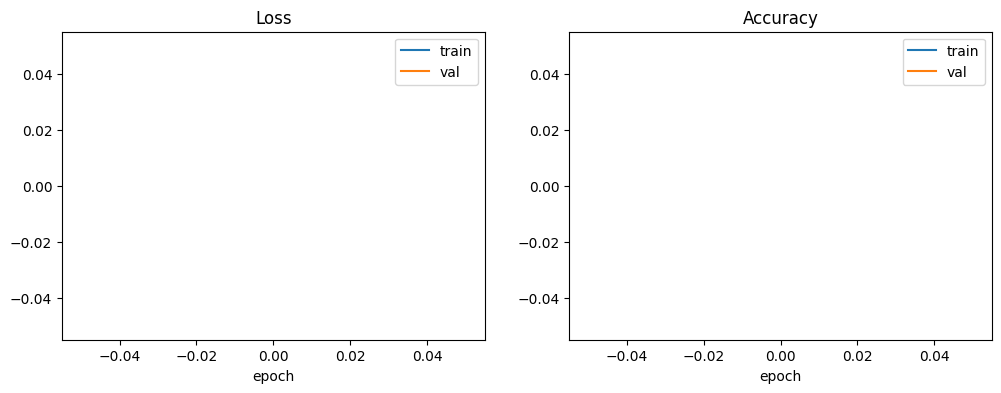

In [43]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(history['train_loss'], label='train')
ax[0].plot(history['val_loss'], label='val')
ax[0].set_title('Loss')
ax[0].set_xlabel('epoch')
ax[0].legend()

ax[1].plot(history['train_acc'], label='train')
ax[1].plot(history['val_acc'], label='val')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('epoch')
ax[1].legend()

plt.show()

In [28]:
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Loaded best model from epoch {ckpt['epoch']} "
      f"(val loss {ckpt['val_loss']:.4f}, val acc {ckpt['val_acc']:.4f})")

Loaded best model from epoch 2 (val loss 0.0364, val acc 0.9877)


In [29]:
import numpy as np

@torch.no_grad()
def predict_paths(paths, batch=64):
    probs = []
    buf = []
    for i, p in enumerate(paths):
        try:
            mel = preprocess(p) # CLEAN preprocessing
        except Exception:
            mel = np.zeros((N_MELS, 188), dtype=np.float32)
        buf.append(mel)
        if len(buf) == batch or i == len(paths) - 1:
            x = torch.from_numpy(np.stack(buf)).unsqueeze(1).to(device)
            p_fake = torch.sigmoid(model(x)).cpu().numpy()
            probs.extend(p_fake.tolist())
            buf = []
    return np.array(probs)

In [32]:
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, roc_curve)

def compute_eer(labels, scores):
    fpr, tpr, thr = roc_curve(labels, scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[idx] + fnr[idx]) / 2
    return eer * 100, thr[idx]

def full_report(name, labels, probs, threshold=0.5):
    labels = np.array(labels)
    preds = (probs > threshold).astype(int)
    acc = accuracy_score(labels, preds) * 100
    f1  = f1_score(labels, preds) * 100
    eer, eer_thr = compute_eer(labels, probs)
    cm  = confusion_matrix(labels, preds)

    real_acc = cm[0,0] / cm[0].sum() * 100
    fake_acc = cm[1,1] / cm[1].sum() * 100
    print(f"\n===== {name} (threshold={threshold:.2f}) =====")
    print(f"Accuracy: {acc:.2f}%")
    print(f"F1 (fake): {f1:.2f}%")
    print(f"EER: {eer:.2f}%  (at threshold {eer_thr:.3f})")
    print(f"Per-class acc -> real: {real_acc:.2f}% | fake: {fake_acc:.2f}%")
    print(f"Confusion matrix [rows=true real/fake, cols=pred real/fake]:\n{cm}")
    return {'acc':acc,'f1':f1,'eer':eer,'eer_thr':eer_thr,
            'real_acc':real_acc,'fake_acc':fake_acc}

In [33]:
test_paths, test_labels = build_list(os.path.join(FOR_ROOT, 'testing'))
test_probs = predict_paths(test_paths)
for_metrics = full_report("FoR TEST (seen distribution)", test_labels, test_probs, 0.5)


===== FoR TEST (seen distribution) (threshold=0.50) =====
Accuracy: 88.56%
F1 (fake): 87.58%
EER: 7.51%  (at threshold 0.138)
Per-class acc -> real: 98.76% | fake: 78.82%
Confusion matrix [rows=true real/fake, cols=pred real/fake]:
[[2236   28]
 [ 502 1868]]


In [34]:
import os
ASV_DIR = '/content/data/asv'
os.makedirs(ASV_DIR, exist_ok=True)
!kaggle datasets download -d awsaf49/asvpoof-2019-dataset -p {ASV_DIR}
!df -h /content | tail -1
print("Download done")

Dataset URL: https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset
License(s): ODC Attribution License (ODC-By)
100% 23.6G/23.6G [04:00<00:00, 105MB/s]

overlay         113G  106G  6.8G  95% /
Download done


In [35]:
import zipfile, random, os, shutil

ZIP = '/content/data/asv/asvpoof-2019-dataset.zip'
OUT = '/content/data/asv/subsets'
os.makedirs(OUT, exist_ok=True)
zf = zipfile.ZipFile(ZIP); names = zf.namelist()

eval_protocol  = 'LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt'
train_protocol = 'LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt'
all_eval  = [n for n in names if 'LA_eval/flac'  in n and n.endswith('.flac')]
all_train = [n for n in names if 'LA_train/flac' in n and n.endswith('.flac')]

random.seed(0); eval_subset  = random.sample(all_eval, 1000)
random.seed(1); train_subset = random.sample(all_train, 3000)

# Extract protocols.
zf.extract(eval_protocol, OUT);  zf.extract(train_protocol, OUT)
EVAL_PROTOCOL  = os.path.join(OUT, eval_protocol)
TRAIN_PROTOCOL = os.path.join(OUT, train_protocol)

# Extract eval flacs.
for i, n in enumerate(eval_subset):
    zf.extract(n, OUT)
    if (i+1) % 500 == 0: print(f"  eval {i+1}/1000", flush=True)
# Extract train flacs.
for i, n in enumerate(train_subset):
    zf.extract(n, OUT)
    if (i+1) % 1000 == 0: print(f"  train {i+1}/3000", flush=True)

zf.close()
os.remove(ZIP)
print("Zip deleted. Disk now:")
!df -h /content | tail -1

  eval 500/1000
  eval 1000/1000
  train 1000/3000
  train 2000/3000
  train 3000/3000
Zip deleted. Disk now:
overlay         113G   83G   31G  74% /


In [36]:
import shutil
shutil.copytree(OUT, '/content/drive/MyDrive/deepfake_audio/asv_subsets',
                dirs_exist_ok=True)
print("Subsets backed up to Drive.")

Subsets backed up to Drive.


In [37]:
eval_label_map = {}
with open(EVAL_PROTOCOL) as f:
    for line in f:
        p = line.strip().split()
        if len(p) >= 5:
            eval_label_map[p[1]] = 1 if p[4]=='spoof' else 0

eval_flac_root = os.path.join(OUT, 'LA/LA/ASVspoof2019_LA_eval/flac')
asv_paths, asv_labels = [], []
for fn in os.listdir(eval_flac_root):
    if fn.endswith('.flac'):
        utt = fn.replace('.flac','')
        if utt in eval_label_map:
            asv_paths.append(os.path.join(eval_flac_root, fn))
            asv_labels.append(eval_label_map[utt])
print(f"Eval subset: {len(asv_paths)} (real={asv_labels.count(0)}, fake={asv_labels.count(1)})")

Eval subset: 986 (real=100, fake=886)


In [38]:
asv_probs = predict_paths(asv_paths)
_ = full_report("ASVspoof eval — BEFORE fine-tune", asv_labels, asv_probs, 0.5)


===== ASVspoof eval — BEFORE fine-tune (threshold=0.50) =====
Accuracy: 35.80%
F1 (fake): 44.42%
EER: 31.24%  (at threshold 0.011)
Per-class acc -> real: 100.00% | fake: 28.56%
Confusion matrix [rows=true real/fake, cols=pred real/fake]:
[[100   0]
 [633 253]]


In [39]:
train_label_map = {}
with open(TRAIN_PROTOCOL) as f:
    for line in f:
        p = line.strip().split()
        if len(p) >= 5:
            train_label_map[p[1]] = 1 if p[4]=='spoof' else 0

train_flac_root = os.path.join(OUT, 'LA/LA/ASVspoof2019_LA_train/flac')
real_p, fake_p = [], []
for fn in os.listdir(train_flac_root):
    if fn.endswith('.flac'):
        utt = fn.replace('.flac','')
        if utt in train_label_map:
            (fake_p if train_label_map[utt]==1 else real_p).append(
                os.path.join(train_flac_root, fn))

n = min(len(real_p), len(fake_p))     # balance real/fake
asv_add_paths  = real_p[:n] + fake_p[:n]
asv_add_labels = [0]*n + [1]*n
print(f"ASVspoof-train added: {len(asv_add_paths)} (real={n}, fake={n})")

ASVspoof-train added: 618 (real=309, fake=309)


In [40]:
from torch.utils.data import DataLoader

for_train_paths, for_train_labels = build_list(os.path.join(FOR_ROOT, 'training'))
for_train_paths, for_train_labels = subsample(for_train_paths, for_train_labels, per_class=15000)

merged_paths  = for_train_paths + asv_add_paths
merged_labels = for_train_labels + asv_add_labels
print(f"Merged: {len(merged_paths)} (fake={sum(merged_labels)}, "
      f"real={len(merged_labels)-sum(merged_labels)})")

train_ds = AudioDataset(merged_paths, merged_labels, train=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True,
                          persistent_workers=True)

Merged: 30618 (fake=15309, real=15309)


In [41]:
import torch

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

EPOCHS = 5
best_val_loss = float('inf'); epochs_no_improve = 0
CKPT_PATH2 = '/content/drive/MyDrive/deepfake_audio/checkpoints/best_model_v2.pt'

for epoch in range(1, EPOCHS+1):
    print(f"=== Fine-tune epoch {epoch:02d} ===", flush=True)
    tr_loss, tr_acc = run_epoch(train_loader, training=True, desc=f"train {epoch}")
    va_loss, va_acc = run_epoch(val_loader, training=False, desc=f"val {epoch}")
    scheduler.step(va_loss)
    print(f"Epoch {epoch:02d} | train acc {tr_acc:.4f} | val acc {va_acc:.4f} "
          f"| val loss {va_loss:.4f}", flush=True)
    if va_loss < best_val_loss:
        best_val_loss = va_loss; epochs_no_improve = 0
        torch.save({'model_state': model.state_dict(), 'epoch': epoch}, CKPT_PATH2)
        print("   saved v2", flush=True)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= 2:
            print("Early stop."); break

=== Fine-tune epoch 01 ===
Epoch 01 | train acc 0.9596 | val acc 0.9906 | val loss 0.0289
   saved v2
=== Fine-tune epoch 02 ===
Epoch 02 | train acc 0.9635 | val acc 0.9894 | val loss 0.0330
=== Fine-tune epoch 03 ===
Epoch 03 | train acc 0.9658 | val acc 0.9945 | val loss 0.0163
   saved v2
=== Fine-tune epoch 04 ===
Epoch 04 | train acc 0.9682 | val acc 0.9758 | val loss 0.0766
=== Fine-tune epoch 05 ===
Epoch 05 | train acc 0.9713 | val acc 0.9957 | val loss 0.0138
   saved v2


In [42]:
ckpt = torch.load(CKPT_PATH2, map_location=device)
model.load_state_dict(ckpt['model_state']); model.eval()

print(">>> ASVspoof eval — AFTER fine-tune")
asv_probs_v2 = predict_paths(asv_paths)
_ = full_report("ASVspoof eval — AFTER", asv_labels, asv_probs_v2, 0.5)

print("\n>>> FoR test — AFTER fine-tune (should stay strong)")
test_paths2, test_labels2 = build_list(os.path.join(FOR_ROOT, 'testing'))
_ = full_report("FoR test — AFTER", test_labels2, predict_paths(test_paths2), 0.5)

>>> ASVspoof eval — AFTER fine-tune

===== ASVspoof eval — AFTER (threshold=0.50) =====
Accuracy: 53.85%
F1 (fake): 66.12%
EER: 35.78%  (at threshold 0.212)
Per-class acc -> real: 87.00% | fake: 50.11%
Confusion matrix [rows=true real/fake, cols=pred real/fake]:
[[ 87  13]
 [442 444]]

>>> FoR test — AFTER fine-tune (should stay strong)

===== FoR test — AFTER (threshold=0.50) =====
Accuracy: 96.66%
F1 (fake): 96.64%
EER: 2.63%  (at threshold 0.213)
Per-class acc -> real: 99.34% | fake: 94.09%
Confusion matrix [rows=true real/fake, cols=pred real/fake]:
[[2249   15]
 [ 140 2230]]
